In [ ]:

import bayesian_torch 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from pathlib import Path

# Set random seed for reproducibility
torch.manual_seed(42)

**Bayesian torch** library github.com:IntelLabs/bayesian-torch/

pip-enabled: pip install bayesian-torch

Load the MNIST Dataset

In [ ]:
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./datasets', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./datasets', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Training batches: {len(train_loader)}")

Training batches: 938


##### The Variational LeNet MLP
We swap out nn.Linear for our custom LinearVariational. We also need to adapt the forward function so it catches and sums the KL divergence accumulated by each layer.

posterior sigma parameter is modeled as $rho$ where $sigma = log(1+ exp(rho))$ this ensures that the learned sigma is strictly positive


In [ ]:
from bayesian_torch.layers import LinearReparameterization

prior_mu = 0.0
prior_sigma = 1.0
posterior_mu_init = 0.0
posterior_rho_init = -3.0 #results in an initial sigma of ~0.05

#  Note that the learned parameter Rho represents the Sigma of the normal distribution
#  Sigma = log(1+ exp(rho)) <-- this ensures that Sigma is strictly positive
#  math.log(1+math.exp(-3)) ~= 0.05

class VariationalLeNet(nn.Module):
    def __init__(self):
        super(VariationalLeNet, self).__init__()
        self.fc1 = LinearReparameterization(
            in_features=784,
            out_features=300,
            prior_mean=prior_mu,
            prior_variance=prior_sigma,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )

        self.fc2 = LinearReparameterization(
            in_features=300,
            out_features=100,
            prior_mean=prior_mu,
            prior_variance=prior_sigma,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )

        self.fc3 = LinearReparameterization(
            in_features=100,
            out_features=10,
            prior_mean=prior_mu,
            prior_variance=prior_sigma,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
        )

    def forward(self, x):
        x = x.view(-1, 784)
        kl_sum = 0
        
        x, kl = self.fc1(x)
        kl_sum += kl
        x = F.relu(x)
        
        x, kl = self.fc2(x)
        kl_sum += kl
        x = F.relu(x)
        
        x, kl = self.fc3(x)
        kl_sum += kl
        
        output = F.log_softmax(x, dim=1)
        return output, kl_sum

##### Training Loop 
To train a variational model, we maximize the Evidence Lower Bound (ELBO). In practice, we minimize the Negative ELBO, which is the Cross-Entropy loss plus the weighted KL divergence.

A new hyperparameter is added to define the number of samples from the posterior, i.e. the number of forward passes.

In [ ]:
# Initialize Model, Optimizer, Loss Function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VariationalLeNet().to(device)

# hyperparameters
len_trainset = 60000
len_testset = 10000
epochs = 150
lr = 0.01

# number of posterior samples represents the number of forward passes
# at each forward pass, you're sampling from each parameter distribution
# with each forward pass, you get a slightly different p(y|x) softmax output 
num_posterior_samples = 5 


# Don't add weight decay since the KL divergence functions effectively as weight decay for distribution paramters
optimizer = optim.SGD(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.7)
criterion = nn.CrossEntropyLoss()

print(f"Training on {device}...")
output_path = Path.cwd() / 'output' / 'run_bayesian_torch'
output_path.mkdir(parents=True, exist_ok=True)

model.train()
for epoch in range(1, epochs + 1):
    total_loss = 0
    total_kl = 0
    correct = 0
    
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        output_ = []
        kl_ = []

        # run N forward passes
        for _ in range(num_posterior_samples):
            output, kl = model(data) #output is log_softmax
            output_.append(output)
            kl_.append(kl)

        output = torch.mean(torch.stack(output_), dim=0) # average over monte-carlo (MC) samples
        kl = torch.mean(torch.stack(kl_), dim=0)
        nll_loss = F.nll_loss(output, target)
        #ELBO loss
        loss = nll_loss + (kl / batch_size)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
           
        # Tracking metrics
        total_loss += loss.item()
        total_kl += kl.item()
        
        # Calculate accuracy
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

    
    avg_loss = total_loss / len(train_loader)
    avg_kl = total_kl / len(train_loader)
    accuracy = 100. * correct / len(train_loader.dataset)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Train Epoch: {epoch:02d}/{epochs} | Total Loss: {avg_loss:.4f} "
              f"| KL Divergence: {avg_kl:.2f} | Accuracy: {accuracy:.2f}%")

        # To track weight distribution evolution
        save_dict = {'epoch': epoch, 'state_dict': model.state_dict()}
                    
        torch.save(save_dict, output_path / f'checkpoint_epoch{epoch}.pth.tar')

    scheduler.step()

Training on cuda...
Train Epoch: 01/150 | Total Loss: 1.1448 | KL Divergence: 15.13 | Accuracy: 80.61%
Train Epoch: 05/150 | Total Loss: 0.6105 | KL Divergence: 15.10 | Accuracy: 92.25%
Train Epoch: 10/150 | Total Loss: 0.5802 | KL Divergence: 15.09 | Accuracy: 92.88%
Train Epoch: 15/150 | Total Loss: 0.5772 | KL Divergence: 15.09 | Accuracy: 92.87%
Train Epoch: 20/150 | Total Loss: 0.5755 | KL Divergence: 15.09 | Accuracy: 93.00%
Train Epoch: 25/150 | Total Loss: 0.5760 | KL Divergence: 15.09 | Accuracy: 92.89%
Train Epoch: 30/150 | Total Loss: 0.5758 | KL Divergence: 15.09 | Accuracy: 92.92%
Train Epoch: 35/150 | Total Loss: 0.5757 | KL Divergence: 15.09 | Accuracy: 92.95%
Train Epoch: 40/150 | Total Loss: 0.5759 | KL Divergence: 15.09 | Accuracy: 92.91%
Train Epoch: 45/150 | Total Loss: 0.5771 | KL Divergence: 15.09 | Accuracy: 92.91%
Train Epoch: 50/150 | Total Loss: 0.5754 | KL Divergence: 15.09 | Accuracy: 92.92%
Train Epoch: 55/150 | Total Loss: 0.5754 | KL Divergence: 15.09 | A

#### Evaluate Model

In [ ]:
model.eval()
test_loss = 0
correct = 0

samples = [0, 149, 659, 619, 740, 956]
sample_preds = []

with torch.no_grad():
    for i, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)

        outputs = []
        for _ in range(num_posterior_samples):
            output, kl = model(data)
            outputs.append(output)

        outputs = torch.stack(outputs)
        mean_output = torch.mean(outputs, dim=0)

        test_loss += F.nll_loss(mean_output, target, reduction='sum').item() + (kl / batch_size)  # sum up batch loss
        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()

        if i in samples:
            sample_preds.append(torch.exp(outputs)) #get output probability p(y|x)

test_loss /= len(test_loader.dataset)

print(
    '\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))


Test set: Average loss: 0.5677, Accuracy: 8972/10000 (89.72%)



#### Visualizing Predictive Probability Distributions $P(y \mid x)$ and Uncertainty

**Objective**  
Analyze model confidence and epistemic uncertainty by plotting the stochastic posterior distribution $P(y \mid x)$ obtained across multiple Monte Carlo / variational forward passes.

##### Comparison Categories
* **Correct Predictions (Low Uncertainty):** Samples where predictive density is sharply concentrated on the true class label with minimal variance across stochastic passes.
* **Incorrect Predictions (High Uncertainty):** Misclassified samples exhibiting high variance, low overall confidence, or bimodal distributions spread across competing digit classes.

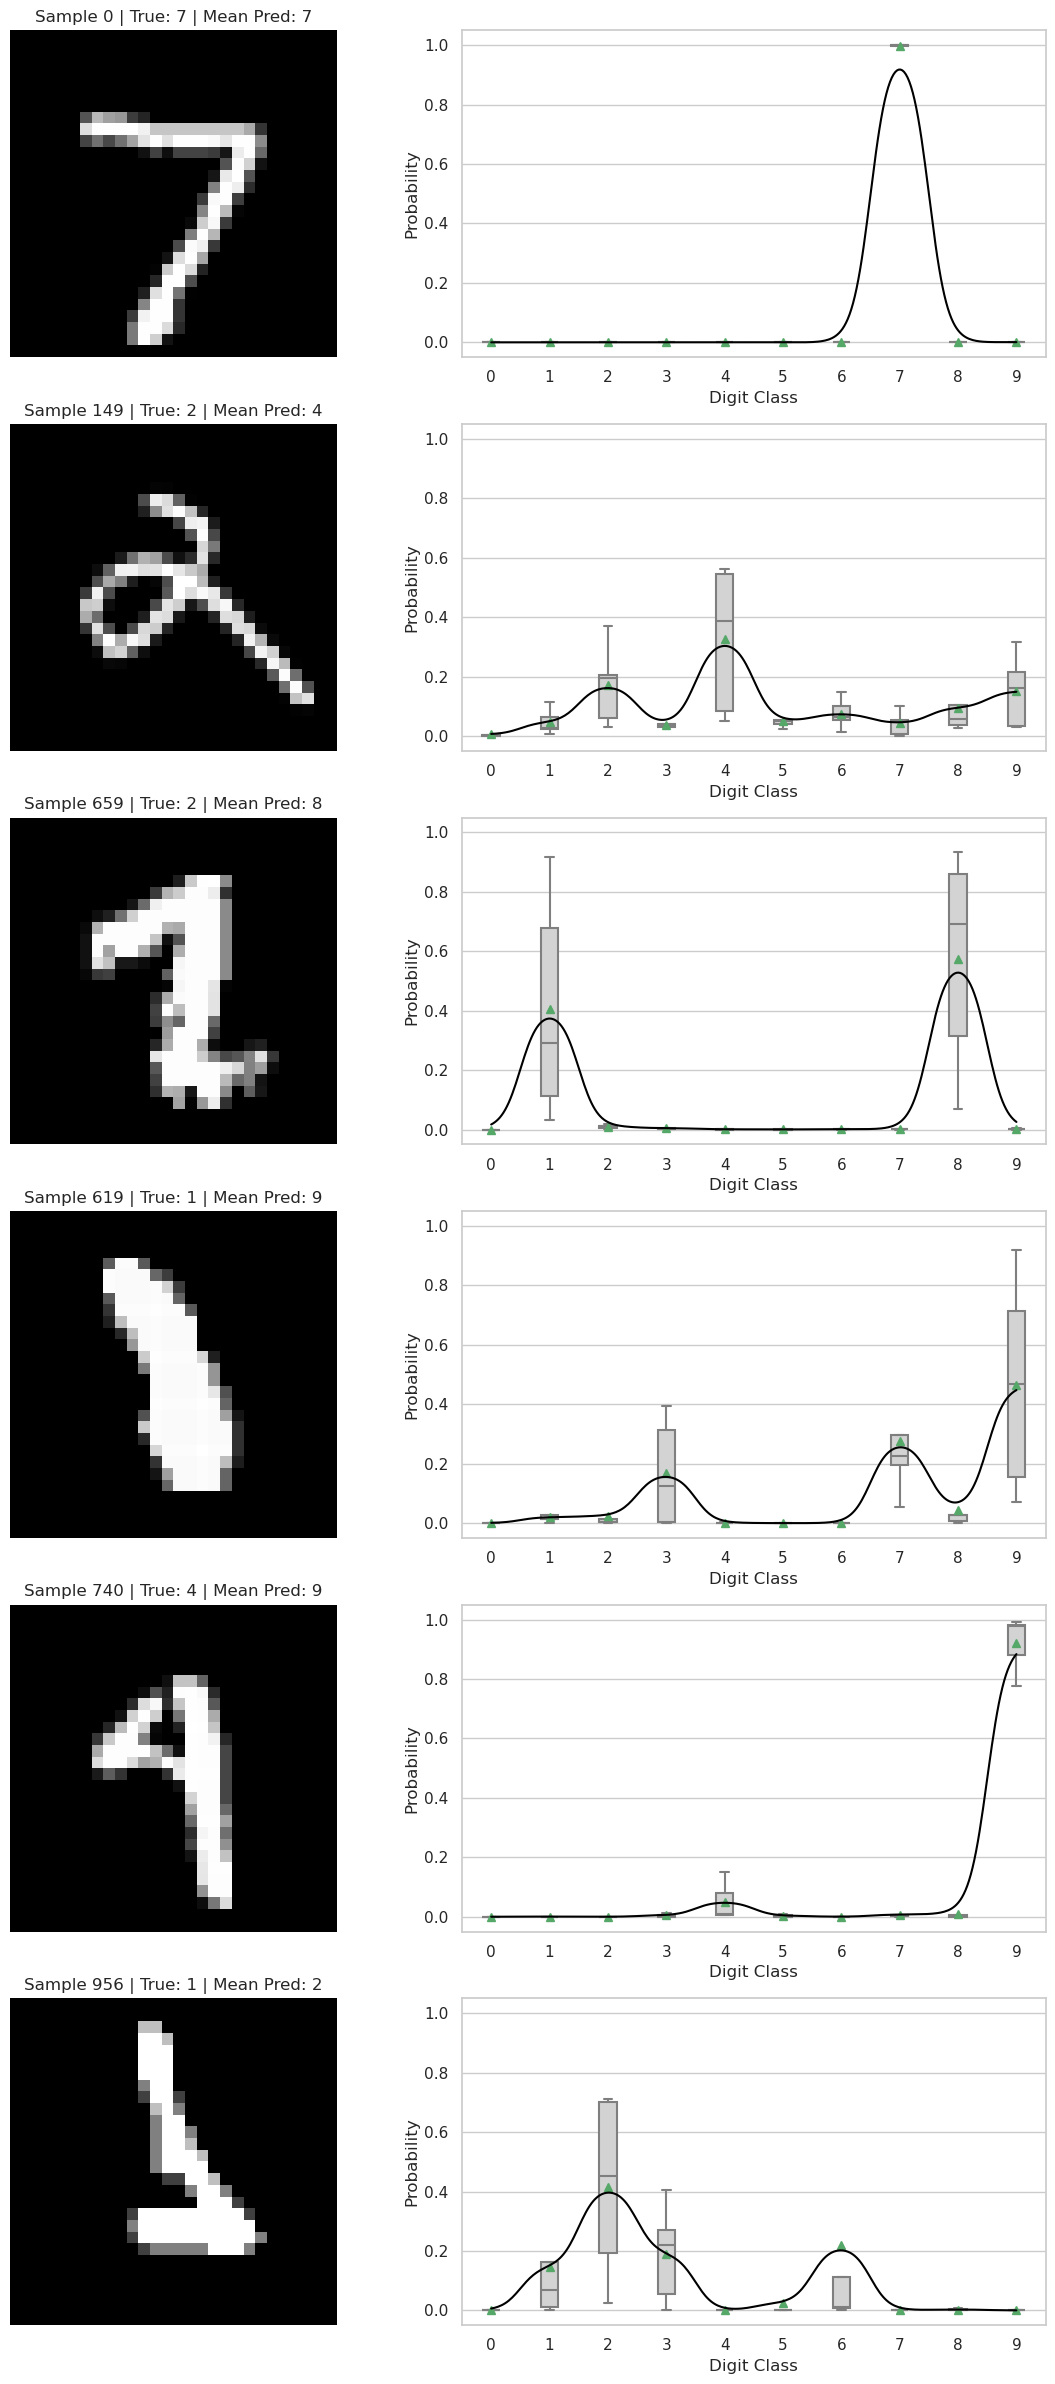

In [ ]:


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4 * len(samples)))

for i, idx in enumerate(samples):
    # 1. Extract image and true label
    img, true_label = test_dataset[idx]
    
    # 2. Reshape tensor to 2D matrix of shape (num_passes, 10)
    preds = sample_preds[i]
    if preds.ndim == 1:
        preds = preds.unsqueeze(0)
    elif preds.ndim > 2:
        preds = preds.reshape(-1, 10)
    
    probs = preds.cpu().numpy()
        
    # 3. Plot the MNIST Image
    ax_img = axes[i, 0]
    ax_img.imshow(img.squeeze(0), cmap='gray')
    mean_pred_class = probs.mean(axis=0).argmax()
    ax_img.set_title(f"Sample {idx} | True: {true_label} | Mean Pred: {mean_pred_class}")
    ax_img.axis('off')
    
    # 4. Plot Boxplot
    ax_box = axes[i, 1]
    
    sns.boxplot(
        data=probs, 
        ax=ax_box, 
        width=0.3, 
        color="lightgray", 
        showmeans=True, 
        fliersize=0,
        zorder=2
    )
    
    # 5. Compute Single Continuous KDE Smooth Curve Across the X-axis
    num_passes = probs.shape[0]
    x_classes = np.arange(10)
    x_all = np.tile(x_classes, num_passes)  # Flattened x coordinates
    p_all = probs.flatten()                  # Flattened probability values
    
    # Fine x-grid for rendering the continuous curve
    x_grid = np.linspace(0, 9, 300)
    
    # Nadaraya-Watson Gaussian Kernel Smoothing
    bandwidth = 0.40  # Adjust bandwidth for more or less smoothing
    weights = np.exp(-0.5 * ((x_grid[:, None] - x_all[None, :]) / bandwidth) ** 2)
    y_kde_line = np.sum(weights * p_all[None, :], axis=1) / (np.sum(weights, axis=1) + 1e-8)
    
    # Plot single continuous line across digits 0-9
    ax_box.plot(
        x_grid, 
        y_kde_line, 
        color="black", 
        linewidth=1.5,
        zorder=4``
    )
    
    # Formatting
    ax_box.set_xlabel("Digit Class")
    ax_box.set_ylabel("Probability")
    ax_box.set_ylim(-0.05, 1.05)
    ax_box.set_xticks(range(10))
    ax_box.set_xticklabels(range(10))

plt.tight_layout()
plt.show()